In [1]:
#speach to text
path_to_mp3_1 = 'freesound_community-fast-count-down-from-10-to-1-105379.mp3'
path_to_mp3_2 = 'freesound_community-000981_jfk-space-race-speech-59951.mp3'

In [2]:
from faster_whisper import WhisperModel

model = WhisperModel("tiny")

segments, info = model.transcribe(path_to_mp3_1)
for segment in segments:
    print("[%.2fs -> %.2fs] %s" % (segment.start, segment.end, segment.text))


[0.00s -> 5.68s]  10, 9, 8, 7, 6, 5, 4, 3, 2, 1.


In [3]:
segments, info = model.transcribe(path_to_mp3_2)
for segment in segments:
    print("[%.2fs -> %.2fs] %s" % (segment.start, segment.end, segment.text))

[0.00s -> 12.18s]  President, Mr. Vice President, Governor, Congressman Thomas, Senator Wiley, and Congressman
[12.18s -> 20.52s]  Miller, Mr. Webb, Mr. Bell, scientists, distinguished guests at Ladies and Gentlemen.
[20.52s -> 26.84s]  I appreciate your President having made me an honorary visiting professor and I will assure
[26.92s -> 30.72s]  you that my first lecture will be a very brief.
[30.72s -> 36.20s]  I am delighted to be here and I am particularly delighted to be here on this occasion.
[36.20s -> 44.04s]  We meet at a college noted for knowledge in a city noted for progress in a state noted
[44.04s -> 48.08s]  for strength and we stand in need of all three.
[48.08s -> 55.96s]  For we meet in an hour of change and challenge in a decade of hope and fear in an age
[56.12s -> 58.84s]  of both knowledge and ignorance.
[58.84s -> 64.48s]  The greater our knowledge increases, the greater our ignorance unfolds.
[64.48s -> 71.68s]  Despite the striking fact that most of the scienti

In [4]:
#text to speach, sound generation
from transformers import pipeline

synthesiser = pipeline("text-to-speech", "suno/bark-small")
speech = synthesiser("Hello, my dog is cooler than you!", forward_params={"do_sample": True})

print("Keys:", speech.keys())
print("Audio type:", type(speech["audio"]))
print("Audio shape:", getattr(speech["audio"], "shape", "No shape attribute"))
print("Audio dtype:", getattr(speech["audio"], "dtype", "No dtype"))
print("Sampling rate:", speech["sampling_rate"])

2026-05-06 19:40:22.653792: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-06 19:40:22.653817: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-06 19:40:22.658723: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 19:40:23.192827: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/

Keys: dict_keys(['audio', 'sampling_rate'])
Audio type: <class 'numpy.ndarray'>
Audio shape: (1, 335040)
Audio dtype: float32
Sampling rate: 24000


In [5]:
import soundfile as sf
import numpy as np

audio = speech["audio"]
if audio.ndim == 2 and audio.shape[1] == 1:
    audio = audio.squeeze(1)   # from (N,1) to (N,)
if audio.ndim == 2 and audio.shape[0] == 1:
    audio = audio.squeeze(0)   # from (1,N) to (N,)

# Ensure float32
audio = audio.astype(np.float32)

sf.write("bark_out.wav", audio, speech["sampling_rate"])

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/nikita/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1


In [2]:
import os

file = os.listdir(path)
files_in_dir = os.listdir(path + '/' + file[0])

print(files_in_dir)

path_to_files = path + '/' + file[0]

base_path = path_to_files + '/' + files_in_dir[3]

files_list = os.listdir(base_path)

data_files = []

for i in range(len(files_list)):
    class_path = os.path.join(base_path, files_list[i])
    path_obj = os.listdir(class_path)
    path_obj_full = [os.path.join(class_path, f) for f in path_obj]
    data_files.append(path_obj_full)

['genres_original', 'features_3_sec.csv', 'features_30_sec.csv', 'images_original']


In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import random

data_x = []
data_y = []
size = (260, 260)

for class_idx, file_list in enumerate(data_files):
    num_samples = len(file_list)
    
    for j in range(num_samples):
        img = Image.open(file_list[j])
        res = img.convert('RGB').resize(size)
        res = np.array(res) / 255.0
        v_stripes = np.hsplit(res, 10)
        data_x.append(v_stripes)
        data_y.append(class_idx)

In [4]:
from sklearn.model_selection import train_test_split

data_x = np.array(data_x)
data_y = np.array(data_y)

x_train, x_test, y_train, y_test = train_test_split(
    data_x, 
    data_y, 
    test_size=0.10, 
    random_state=42,
    stratify=data_y
)

In [5]:
del data_x
del data_y

In [8]:
x_train.shape

(899, 10, 260, 26, 3)

In [7]:
import tensorflow as tf
import keras

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
print("Устройство для вычислений:", tf.test.is_gpu_available())

Версия TensorFlow: 2.14.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Устройство для вычислений: True


2026-05-06 19:48:39.863835: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 19:48:39.864797: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 19:48:39.865568: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [24]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, TimeDistributed, Flatten, GRU, Dense, Dropout, Attention, Input
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity
import tempfile

class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, use_scale=False, **kwargs):
        super().__init__(**kwargs)
        self.use_scale = use_scale
        self.attention = Attention(use_scale=use_scale)
    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        super().build(input_shape)
    def call(self, x):
        e = tf.matmul(x, self.W)
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e, axis=-1)
        context = tf.reduce_sum(x * tf.expand_dims(alpha, -1), axis=1)
        return context

    def get_prunable_weights(self):
        return [self.W]

def build_pruned_model(final_sparsity, input_shape=(10,260,26,3)):
    pruning_schedule = sparsity.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=2000, 
        frequency=100
    )

    model = keras.Sequential([
        Input(shape=input_shape),
        TimeDistributed(Conv2D(7, (3,3), padding='same', strides=2)),
        keras.layers.Dropout(0.25),
        TimeDistributed(MaxPooling2D((2,4))),
        TimeDistributed(Conv2D(7, (3,3), padding='same', activation='relu', strides=2)),
        keras.layers.Dropout(0.25),
        TimeDistributed(Flatten()),

        sparsity.prune_low_magnitude(GRU(64, return_sequences=True, activation='tanh'), pruning_schedule),
        sparsity.prune_low_magnitude(SelfAttention(use_scale=True), pruning_schedule),
        keras.layers.Dropout(0.3),
    
        sparsity.prune_low_magnitude(Dense(128, activation='relu'), pruning_schedule),
        keras.layers.Dropout(0.3),
        sparsity.prune_low_magnitude(Dense(256, activation='relu'), pruning_schedule),
        keras.layers.Dropout(0.3),
        sparsity.prune_low_magnitude(Dense(128), pruning_schedule),
        keras.layers.Dropout(0.3),
        sparsity.prune_low_magnitude(Dense(10, activation='softmax'), pruning_schedule)
        ])

    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

    return model


sparsities = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9] 
results = [] 

x_small = x_train[:1000]
y_small = y_train[:1000]

for sp in sparsities:
    print(f"\nTraining with final_sparsity = {sp}")
    model = build_pruned_model(sp)
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, mode='min',
                                               restore_best_weights=True)
    pruning_cb = sparsity.UpdatePruningStep()
    
    history = model.fit(x_small, y_small,
                        validation_split=0.15,
                        epochs=200,
                        batch_size=16,
                        callbacks=[pruning_cb, early_stop],
                        verbose=0)

    test_loss, keras_test_acc = model.evaluate(x_test, y_test)
    best_acc = keras_test_acc
    
    stripped = sparsity.strip_pruning(model)
    total_params = 0
    nonzero_params = 0
    for w in stripped.weights:
        arr = w.numpy()
        total_params += arr.size
        nonzero_params += np.count_nonzero(arr)
    nonzero_ratio = nonzero_params / total_params
    
    results.append((sp, best_acc, nonzero_ratio))
    print(f"  Sparsity={sp}, best test_acc={best_acc:.4f}, nonzero_ratio={nonzero_ratio:.2f}")


Training with final_sparsity = 0.0


2026-05-06 20:28:27.528292: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4070 SUPER" frequency: 2475 num_cores: 56 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 50331648 shared_memory_size_per_multiprocessor: 102400 memory_size: 10289348608 bandwidth: 504048000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2026-05-06 20:28:28.889670: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForc

4/4 [==============================] - 0s 4ms/step - loss: 1.2921 - accuracy: 0.6300
  Sparsity=0.0, best test_acc=0.6300, nonzero_ratio=1.00

Training with final_sparsity = 0.3


2026-05-06 20:29:56.817644: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4070 SUPER" frequency: 2475 num_cores: 56 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 50331648 shared_memory_size_per_multiprocessor: 102400 memory_size: 10289348608 bandwidth: 504048000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2026-05-06 20:29:58.222325: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForc

4/4 [==============================] - 0s 4ms/step - loss: 1.4249 - accuracy: 0.5800
  Sparsity=0.3, best test_acc=0.5800, nonzero_ratio=0.70

Training with final_sparsity = 0.5


...

4/4 [==============================] - 0s 4ms/step - loss: 1.3291 - accuracy: 0.5900
  Sparsity=0.7, best test_acc=0.5900, nonzero_ratio=0.31

Training with final_sparsity = 0.8


2026-05-06 20:34:28.467862: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4070 SUPER" frequency: 2475 num_cores: 56 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 50331648 shared_memory_size_per_multiprocessor: 102400 memory_size: 10289348608 bandwidth: 504048000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2026-05-06 20:34:29.838915: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForc

4/4 [==============================] - 0s 4ms/step - loss: 1.5691 - accuracy: 0.4300
  Sparsity=0.8, best test_acc=0.4300, nonzero_ratio=0.21

Training with final_sparsity = 0.9


2026-05-06 20:35:59.708197: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4070 SUPER" frequency: 2475 num_cores: 56 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 50331648 shared_memory_size_per_multiprocessor: 102400 memory_size: 10289348608 bandwidth: 504048000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2026-05-06 20:36:01.115342: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForc

4/4 [==============================] - 0s 4ms/step - loss: 1.7733 - accuracy: 0.3500
  Sparsity=0.9, best test_acc=0.3500, nonzero_ratio=0.11


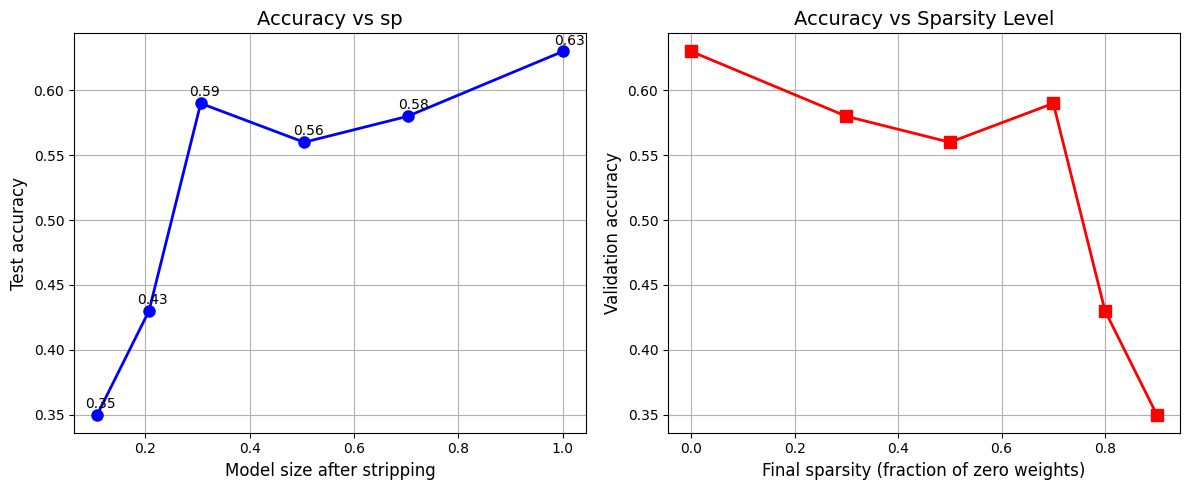

In [32]:
import matplotlib.pyplot as plt

results = np.array(results)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(results[:,2], results[:,1], 'bo-', linewidth=2, markersize=8)
plt.xlabel("Model size after stripping", fontsize=12)
plt.ylabel("Test accuracy", fontsize=12)
plt.title("Accuracy vs sp", fontsize=14)
plt.grid(True)
for sp, acc, size in results:
    plt.annotate(f"{acc:.2f}", ((1-sp), acc), textcoords="offset points", xytext=(5,5), ha='center')

plt.subplot(1,2,2)
plt.plot(results[:,0], results[:,1], 'rs-', linewidth=2, markersize=8)
plt.xlabel("Final sparsity (fraction of zero weights)", fontsize=12)
plt.ylabel("Validation accuracy", fontsize=12)
plt.title("Accuracy vs Sparsity Level", fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

